In [77]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')



In [78]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/DS 3000/station_summary_model_encoded.csv")
print("Raw shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw shape: (242417, 26)


,id,latitude,longitude,ports,power_kw,is_fast_dc,total_power_kw,total_evs,avg_battery,SUV,...,Van_pct,mostly_fast_dc,high_ev_count,power_class_AC_L1_(<7.5kW),power_class_AC_L2_(7.5-21kW),power_class_DC_FAST_(50-149kW),power_class_DC_ULTRA_(>=150kW),power_class_UNKNOWN,power_tier_Level 2,power_tier_Ultra DC
0,2389,34.040539,-118.271387,1,3.7,False,3.7,11,88.181818,6,...,0.0,False,True,True,False,False,False,False,True,False
1,2391,34.059133,-118.248589,1,50.0,True,50.0,11,88.181818,6,...,0.0,True,True,False,False,True,False,False,False,False
2,2396,38.576769,-121.495022,1,3.7,False,3.7,11,88.181818,6,...,0.0,False,True,True,False,False,False,False,True,False
3,2399,38.438052,-122.711357,1,NaN,False,NaN,11,88.181818,6,...,0.0,False,True,False,False,False,False,True,True,False
4,2441,34.145138,-118.152655,1,3.7,False,3.7,11,88.181818,6,...,0.0,False,True,True,False,False,False,False,True,False


In [79]:
# building charging itme varible
df["power_kw"] = pd.to_numeric(df["power_kw"], errors="coerce")
df["avg_battery"] = pd.to_numeric(df["avg_battery"], errors="coerce")

# replace invalid power values
df.loc[df["power_kw"] <= 0, "power_kw"] = np.nan

# create the estimated charging time
df["charge_time_est_mins"] = (df["avg_battery"] / df["power_kw"]) * 60

print("Missing charging time before drop:", df["charge_time_est_mins"].isna().sum())

# drop the rows with invalid charge time
df = df.dropna(subset=["charge_time_est_mins"]).reset_index(drop=True)
print("After drop:", df.shape)

# remove the extreme outliers (1%–99%)
Q1 = df["charge_time_est_mins"].quantile(0.01)
Q3 = df["charge_time_est_mins"].quantile(0.99)
df = df[(df["charge_time_est_mins"] >= Q1) & (df["charge_time_est_mins"] <= Q3)].reset_index(drop=True)
print("After outlier removal:", df.shape)
df[["avg_battery", "power_kw", "charge_time_est_mins"]].describe()

Missing charging time before drop: 4690
After drop: (237727, 27)
After outlier removal: (234407, 27)


,avg_battery,power_kw,charge_time_est_mins
count,234407.000000,234407.000000,234407.000000
mean,79.537890,29.145353,666.666555
std,6.262990,49.961425,576.769947
min,75.000000,2.700000,15.000000
25%,75.000000,3.700000,204.545455
50%,75.000000,11.000000,409.090909
75%,88.181818,22.000000,1429.975430
max,88.181818,351.000000,1763.636364


In [80]:
# select features
features = [
    "power_kw",
    "total_power_kw",
    "ports",
    "avg_battery",
    "total_evs"
]

# declare the target variable
target = "charge_time_est_mins"

# feature matrix for X(features) and Y(target)
X = df[features]
y = df[target]

In [81]:
# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (187525, 5) | Test shape: (46882, 5)


In [82]:
#function for plotting the feature coefficients
def plot_coefficients(model, model_name, X_train):

    # extract coefficients for each feature
    coefs = model.named_steps[list(model.named_steps.keys())[-1]].coef_
    feature_names = X_train.columns

    # build dataframe for feature importance
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs
    }).sort_values(by='Coefficient', key=abs, ascending=False)

    # plot the coefficients
    plt.figure(figsize=(8,5))
    plt.barh(coef_df['Feature'], coef_df['Coefficient'])
    plt.xlabel("Coefficient Value")
    plt.title(f"{model_name} Feature Coefficients")
    plt.tight_layout()
    plt.show()

    return coef_df

RIDGE:

In [83]:
# create the ridge pipeline (normalizing using standard scaler)
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha = 1.0))
])
ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge())])

In [84]:
#do 10-fold cv (9 train + 1 test) and return mean-squared-error values
ridge_mse_scores = -cross_val_score(
    ridge_pipeline,
    X_train,
    y_train,
    cv = 10,
    scoring = 'neg_mean_squared_error'
)

#calculate the mean of the 10 cv values
ridge_mean_mse = np.mean(ridge_mse_scores)

#run prediction using the test set
y_pred = ridge_pipeline.predict(X_test)

#get the mean-absolute-error and root-mean-squared-error
ridge_mae = mean_absolute_error(y_test, y_pred)
ridge_rmse = np.sqrt(ridge_mean_mse)


In [85]:
#print results from initial alpha value model
print("Ridge Regression Performance:")
print("-----------------------------")
print(f"10-fold CV Mean Squared Error (MSE): {ridge_mean_mse:,.2f} minutes²")
print(f"Root Mean Squared Error (RMSE, CV): {ridge_rmse:,.2f} minutes")
print(f"Mean Absolute Error (MAE, test set): {ridge_mae:,.2f} minutes")

Ridge Regression Performance:
-----------------------------
10-fold CV Mean Squared Error (MSE): 138,509.88 minutes²
Root Mean Squared Error (RMSE, CV): 372.17 minutes
Mean Absolute Error (MAE, test set): 299.36 minutes


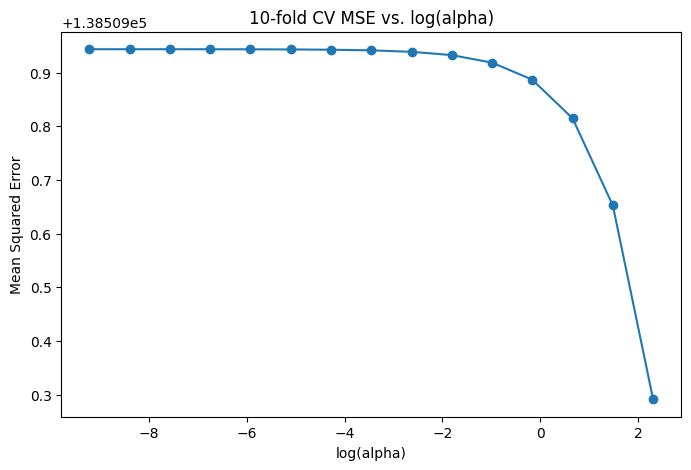

In [86]:
#create alpha values & empty list
alphas = np.logspace(-4, 1, 15)
ridge_cv_mse_list = []

#get the cv mean-squared-values for each alpha
for al in alphas:
    ridge = Ridge(alpha=al)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', ridge)
    ])
    mse_scores = -cross_val_score(pipeline, X_train, y_train, cv = 10, scoring = 'neg_mean_squared_error')
    #get the mean of the mse's for each fold
    ridge_cv_mse_list.append(np.mean(mse_scores))

#plot the alpha values vs the mse to see best alpha value
plt.figure(figsize=(8,5))
plt.plot(np.log(alphas), ridge_cv_mse_list, marker = 'o')
plt.xlabel('log(alpha)')
plt.ylabel('Mean Squared Error')
plt.title('10-fold CV MSE vs. log(alpha)')
plt.show()

In [87]:
#find the index of the smallest mse value
best_index = np.argmin(ridge_cv_mse_list)

#find the related alpha value
best_alpha = alphas[best_index]

print("Best actual regularization parameter (alpha):", best_alpha)
print("Corresponding 10-fold CV MSE:", ridge_cv_mse_list[best_index])


Best actual regularization parameter (alpha): 10.0
Corresponding 10-fold CV MSE: 138509.29158788238


In [88]:
#retrain using the calculated best alpha value
ridge_best = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha))
])
ridge_best.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge', Ridge(alpha=np.float64(10.0)))])

In [89]:
# predictions using the new model
y_pred = ridge_best.predict(X_test)

# metrics for the new ridge model
ridge_mse_test = mean_squared_error(y_test, y_pred)
ridge_rmse_test = np.sqrt(ridge_mse_test)
ridge_mae_test = mean_absolute_error(y_test, y_pred)
ridge_r2_test = r2_score(y_test, y_pred)

print(f"Ridge Test Set Performance Values:")
print(f"RMSE: {ridge_rmse_test:.2f} minutes")
print(f"MAE: {ridge_mae_test:.2f} minutes")
print(f"R²: {ridge_r2_test:.3f}")

Ridge Test Set Performance Values:
RMSE: 371.92 minutes
MAE: 299.38 minutes
R²: 0.584


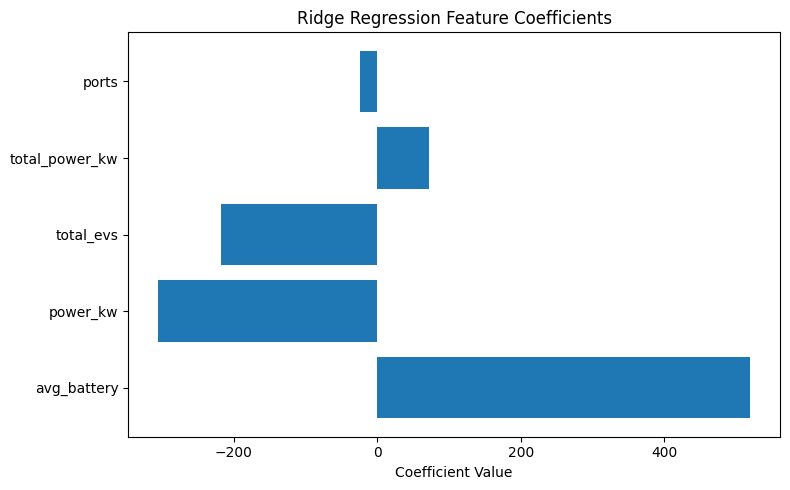

,Feature,Coefficient
3,avg_battery,519.944905
0,power_kw,-305.856777
4,total_evs,-217.339504
1,total_power_kw,71.789612
2,ports,-24.116382


In [90]:
# call the plot coefficient function
plot_coefficients(ridge_best, "Ridge Regression", X_train)

#positive values increase estimated charge time
#negative values decrease estimated charging time

LASSO:


In [91]:
# create the ridge pipeline (normalizing using standard scaler)
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])

lasso_pipeline.fit(X_train, y_train)

#do 10-fold cv (9 train + 1 test) and return mean-squared-error values
lasso_mse_scores = -cross_val_score(
    lasso_pipeline,
    X_train,
    y_train,
    cv = 10,
    scoring = 'neg_mean_squared_error'
)

#calculate the mean of the 10 cv values
lasso_mean_mse = np.mean(lasso_mse_scores)

#run prediction using the test set
y_pred = lasso_pipeline.predict(X_test)

#get the mean-absolute-error and root-mean-squared-error
lasso_mae = mean_absolute_error(y_test, y_pred)
lasso_rmse = np.sqrt(lasso_mean_mse)


In [92]:
#print results from initial alpha value model
print("Lasso Regression Performance:")
print("-----------------------------")
print(f"10-fold CV Mean Squared Error (MSE): {lasso_mean_mse:,.2f} minutes²")
print(f"Root Mean Squared Error (RMSE, CV): {lasso_rmse:,.2f} minutes")
print(f"Mean Absolute Error (MAE, test set): {lasso_mae:,.2f} minutes")

Lasso Regression Performance:
-----------------------------
10-fold CV Mean Squared Error (MSE): 138,503.52 minutes²
Root Mean Squared Error (RMSE, CV): 372.16 minutes
Mean Absolute Error (MAE, test set): 299.46 minutes


In [93]:
# get coefficients for each feature in trained lasso model
lasso_coefs = lasso_pipeline.named_steps['lasso'].coef_

#get features where the coefficient is zero
zeroed_features = X_train.columns[lasso_coefs == 0]
print("Features set to zero by Lasso:", list(zeroed_features))

Features set to zero by Lasso: []


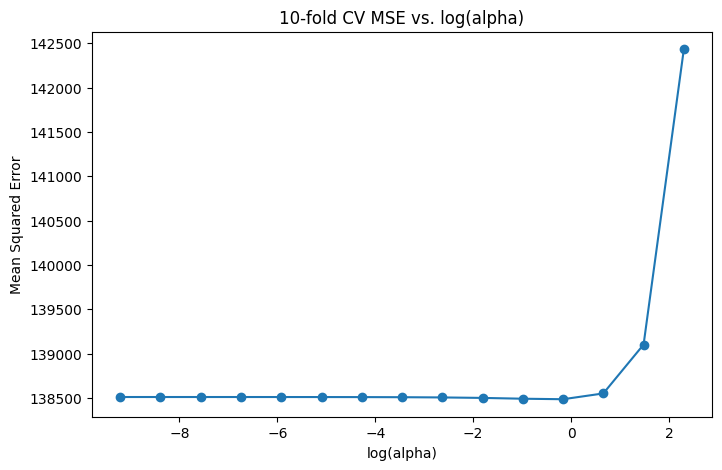

Best Lasso alpha: 0.8483428982440726
Corresponding 10-fold CV MSE: 138485.08033908444


In [94]:
#create alpha values & empty list
alphas = np.logspace(-4, 1, 15)
lasso_cv_mse_list = []

#get the cv mean-squared-values for each alpha
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', lasso)
    ])
    mse_scores = -cross_val_score(pipeline, X_train, y_train, cv = 10, scoring = 'neg_mean_squared_error')
    #get the mean of the mse's for each fold
    lasso_cv_mse_list.append(np.mean(mse_scores))

#plot the alpha values vs the mse to see best alpha value
plt.figure(figsize=(8,5))
plt.plot(np.log(alphas), lasso_cv_mse_list, marker = 'o')
plt.xlabel('log(alpha)')
plt.ylabel('Mean Squared Error')
plt.title('10-fold CV MSE vs. log(alpha)')
plt.show()

#find the index of the smallest mse value
best_index = np.argmin(lasso_cv_mse_list)

#find the related alpha value
best_alpha = alphas[best_index]

print("Best Lasso alpha:", best_alpha)
print("Corresponding 10-fold CV MSE:", lasso_cv_mse_list[best_index])

In [95]:
#retrain using the calculated best alpha value
lasso_best = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=best_alpha, max_iter=10000))
])
lasso_best.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 Lasso(alpha=np.float64(0.8483428982440726), max_iter=10000))])

In [96]:
# predictions using the new model
y_pred = lasso_best.predict(X_test)

# metrics for new lasso model
lasso_mse_test = mean_squared_error(y_test, y_pred)
lasso_rmse_test = np.sqrt(lasso_mse_test)
lasso_mae_test = mean_absolute_error(y_test, y_pred)
lasso_r2_test = r2_score(y_test, y_pred)

print(f"Lasso Test Set Performance:")
print(f"RMSE: {lasso_rmse_test:.2f} minutes")
print(f"MAE: {lasso_mae_test:.2f} minutes")
print(f"R²: {lasso_r2_test:.3f}")

#get features where the coefficient is zero again for new model
lasso_coefs = lasso_best.named_steps['lasso'].coef_
zeroed_features = X_train.columns[lasso_coefs == 0]
print("Features set to zero by Lasso:", list(zeroed_features))

Lasso Test Set Performance:
RMSE: 372.01 minutes
MAE: 300.25 minutes
R²: 0.584
Features set to zero by Lasso: []


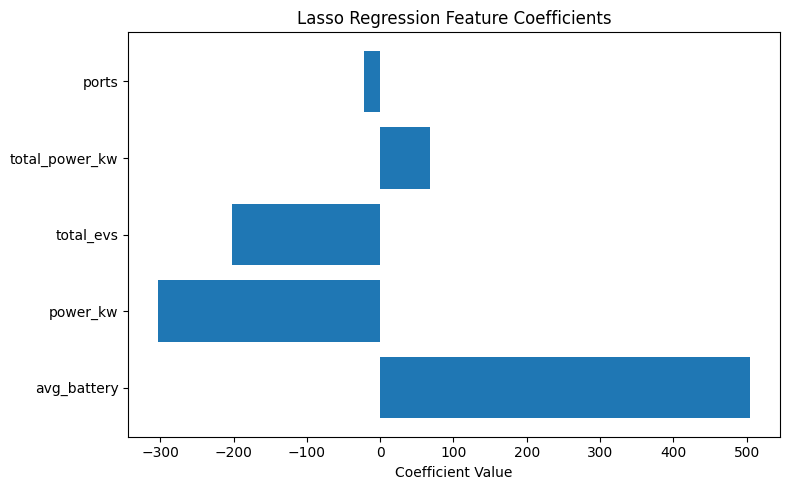

,Feature,Coefficient
3,avg_battery,505.197018
0,power_kw,-303.345083
4,total_evs,-202.264491
1,total_power_kw,68.570294
2,ports,-22.538048


In [97]:
# call the plot coefficient function
plot_coefficients(lasso_best, "Lasso Regression", X_train)

ELASTIC NET:

In [98]:
# create elastic net pipeline with standard scaler normalization
elastic_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet())
])

# values for regularzation strength
# values for l1 ratio (0 = pure ridge & 1 = pure lasso)
param_grid = {
    'elastic__alpha': [0.01, 0.1, 1, 10],
    'elastic__l1_ratio': [0.1, 0.5, 0.7, 1.0]
}

# GridSearchCV tries all the combos of alpha and l1 ratio values
grid = GridSearchCV(elastic_pipe, param_grid, cv=10, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

#retrieves model with the best parameters
elastic_best_model = grid.best_estimator_

#use the best model to predict
y_pred = elastic_best_model.predict(X_test)

# get metrics for the new model
elastic_mse_test = mean_squared_error(y_test, y_pred)
elastic_rmse_test = np.sqrt(elastic_mse_test)
elastic_mae_test = mean_absolute_error(y_test, y_pred)
elastic_r2_test = r2_score(y_test, y_pred)

print(f"Elastic Net Test Set Performance:")
print(f"RMSE: {elastic_rmse_test:.2f} minutes")
print(f"MAE: {elastic_mae_test:.2f} minutes")
print(f"R²: {elastic_r2_test:.3f}")
print("Best Hyperparameters:", grid.best_params_)

Elastic Net Test Set Performance:
RMSE: 372.03 minutes
MAE: 300.41 minutes
R²: 0.584
Best Hyperparameters: {'elastic__alpha': 1, 'elastic__l1_ratio': 1.0}


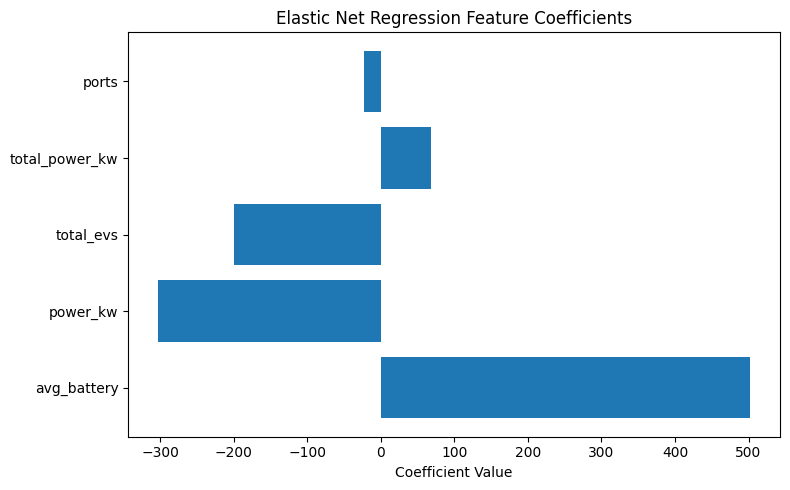

,Feature,Coefficient
3,avg_battery,502.507008
0,power_kw,-302.890127
4,total_evs,-199.516460
1,total_power_kw,67.990612
2,ports,-22.256433


In [99]:
# call the plot coefficient function
plot_coefficients(elastic_best_model, "Elastic Net Regression", X_train)

In [100]:
# get best score from grid search
best_cv_mse = -grid.best_score_

#get mean-squared-error
elastic_cv_rmse = np.sqrt(best_cv_mse)

print(f"Elastic Net Best CV MSE:  {best_cv_mse:.2f}")
print(f"Elastic Net Best CV RMSE: {elastic_cv_rmse:.2f} minutes")

Elastic Net Best CV MSE:  138487.69
Elastic Net Best CV RMSE: 372.14 minutes


In [101]:
#print all the results from the three models
results_df = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Elastic Net'],
    'CV RMSE': [ridge_rmse, lasso_rmse, elastic_cv_rmse],
    'Test RMSE': [ridge_rmse_test, lasso_rmse_test, elastic_rmse_test],
    'Test MAE': [ridge_mae_test, lasso_mae_test, elastic_mae_test],
    'Test R²': [ridge_r2_test, lasso_r2_test, elastic_r2_test]
})

print(results_df)

         Model     CV RMSE   Test RMSE    Test MAE   Test R²
0        Ridge  372.169151  371.920417  299.378459  0.584089
1        Lasso  372.160614  372.005574  300.253583  0.583898
2  Elastic Net  372.139343  372.029714  300.413406  0.583844


Note on feature importance:
For all of the regularized models, 'avg_battery' was the most influential predictor of charging time, 'power_kw' was the second. The Lasso model did not zero out any of the features (indicated above), meaning that all the predictors contribute meaningfully
.